In [2]:
import pandas as pd
df = pd.read_csv("heart.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    11
0     5
Name: target, dtype: int64


In [3]:
X = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(pred[:10])

[1 0 1 1]


In [5]:
from sklearn.metrics import(
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
print(acc, prec, rec, f1)
print(cm)

0.25 0.3333333333333333 0.5 0.4
[[0 2]
 [1 1]]


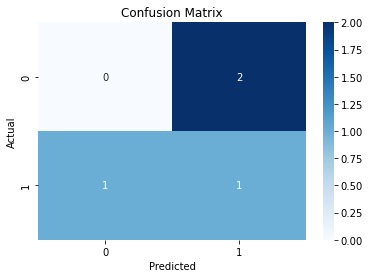

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap (cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print(accuracy_score(y_test, pred_knn))

0.5


In [12]:
for k in[1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    acc_k = accuracy_score(y_test, pred_k)
    print("k=", k, "-> Accuracy:", acc_k)

k= 1 -> Accuracy: 0.25
k= 3 -> Accuracy: 0.25
k= 5 -> Accuracy: 0.5
k= 7 -> Accuracy: 0.5
k= 9 -> Accuracy: 0.5
